<a href="https://colab.research.google.com/github/mbaker21231/MicroII-Sandbox/blob/main/BranderTaylor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulating the Brander-Taylor model

We have two differential equations that we are trying to simulate. Here are the resource dynamics (fairly standard equation):

$$
\frac{dS}{dt}=rS(1-S/K)-\alpha\beta L S
$$
Population dynamics:

$$
\frac{dL}{dt}=L(b-d+\theta\alpha\beta S)
$$

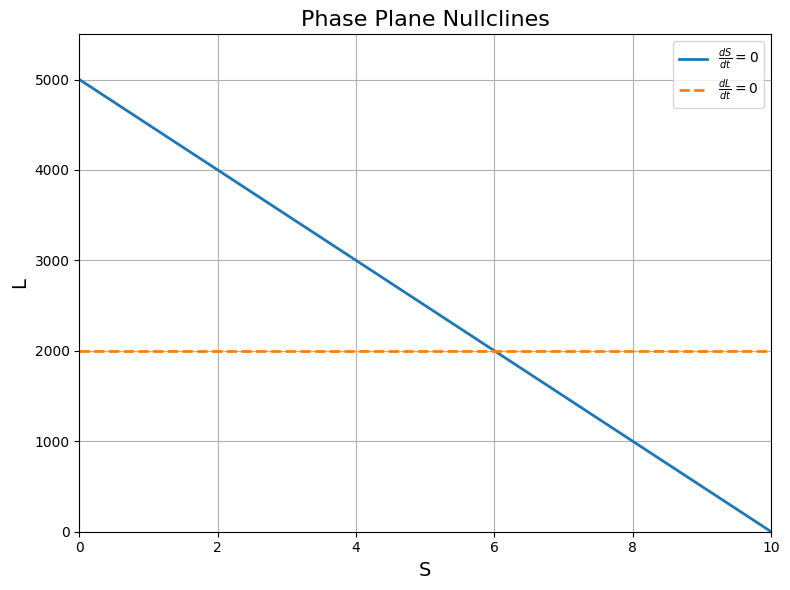

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters (you can adjust these)
r = 1.0
K = 10.0
alpha = 0.001
beta = 0.2
theta = 0.5
b = 0.4
d = 0.6

# Derived constants
A = alpha * beta
B = theta * alpha * beta

# Range of S values
S_vals = np.linspace(0, K, 400)

# Nullclines:
# dS/dt = 0 => L = (r / (alpha * beta)) * (1 - S / K)
L_nullcline_S = (r / A) * (1 - S_vals / K)

# dL/dt = 0 => S = (d - b) / (theta * alpha * beta) => horizontal line
S_star = (d - b) / B
L_nullcline_L = np.full_like(S_vals, S_star)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(S_vals, L_nullcline_S, label=r"$\frac{dS}{dt} = 0$", linewidth=2)
plt.plot(S_vals, L_nullcline_L, '--', label=r"$\frac{dL}{dt} = 0$", linewidth=2)

# Labels and styling
plt.xlabel("S", fontsize=14)
plt.ylabel("L", fontsize=14)
plt.title("Phase Plane Nullclines", fontsize=16)
plt.xlim(0, K)
plt.ylim(0, max(np.nanmax(L_nullcline_S), np.nanmax(L_nullcline_L)) * 1.1)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


Some notes: above the orange line, population is increasing. Below, decreasing. Above the blue line, the resource stock is decreasing. Bellow, decreasing.

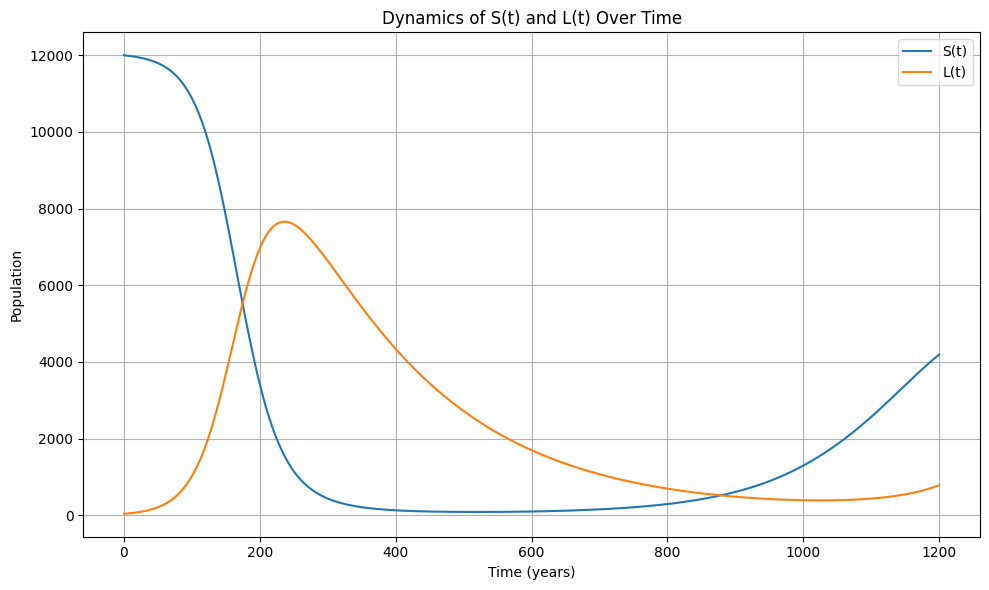

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# === Adjustable Parameters ===
r = .01            # Intrinsic growth rate of S
K = 12000          # Carrying capacity
alpha = 0.00001    # Interaction coefficient
beta = 0.4         # Interaction coefficient
theta = .8          # Efficiency of resource into growth for L
b = 0.005              # Natural birth rate of L
d = 0.01            # Death rate of L

# Initial conditions
S0 = 12000.0        # Initial S
L0 = 40.0         # Initial L

# Time settings
t_start = 0
t_end = 1200       # Time horizon in years
t_points = 1200    # Resolution of time steps
t_eval = np.linspace(t_start, t_end, t_points)

# === System of Differential Equations ===
def system(t, y, r, K, alpha, beta, theta, b, d):
    S, L = y
    dSdt = r * S * (1 - S / K) - alpha * beta * L * S
    dLdt = L * (b - d + theta * alpha * beta * S)
    return [dSdt, dLdt]

# === Solve the system ===
sol = solve_ivp(system, (t_start, t_end), [S0, L0], t_eval=t_eval,
                args=(r, K, alpha, beta, theta, b, d))

# === Plotting ===
plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label="S(t)", color='tab:blue')
plt.plot(sol.t, sol.y[1], label="L(t)", color='tab:orange')

plt.title("Dynamics of S(t) and L(t) Over Time")
plt.xlabel("Time (years)")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
